# RQ1 Prompt Comparison - CodeCarbon Energy Analysis

**Purpose**: Hardware-level energy analysis for CWE-based prompt re-run experiments

**Experiments**:
- 4B Instruct Few-shot (New CWE prompts)
- 4B Thinking Few-shot (New CWE prompts)
- 30B Instruct Few-shot (New CWE prompts)
- 30B Thinking Few-shot (New CWE prompts)

**Focus**: Energy consumption breakdown (CPU/GPU/RAM), cross-validation with energy_tracking.json

## 1. Setup and Load Data

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Paths
RESULTS_MARS = Path('../results/mars_rerun')
RESULTS_RUNPOD = Path('../results/runpod_rerun')
OUTPUT_DIR = Path('../results/analysis_prompt_comparison')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"Mars results: {RESULTS_MARS}")
print(f"RunPod results: {RESULTS_RUNPOD}")
print(f"Output directory: {OUTPUT_DIR}")

Mars results: ../results/mars_rerun
RunPod results: ../results/runpod_rerun
Output directory: ../results/analysis_prompt_comparison


## 2. Configure Experiments

In [2]:
# Experiment configuration
EXPERIMENTS = {
    '4b_instruct': {
        'name': '4B Instruct (New CWE)',
        'results_dir': RESULTS_MARS,
        'codecarbon': 'codecarbon_baseline_sa-few',
        'energy_json': 'Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251101-200224_energy_tracking.json',
        'exp_base': 'Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251101-200224',
        'model_type': 'Instruct',
        'model_size': '4B',
        'infrastructure': 'Mars RTX A5000'
    },
    '4b_thinking': {
        'name': '4B Thinking (New CWE)',
        'results_dir': RESULTS_MARS,
        'codecarbon': 'codecarbon_thinking_sa-few',
        'energy_json': 'Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251101-200857_energy_tracking.json',
        'exp_base': 'Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251101-200857',
        'model_type': 'Thinking',
        'model_size': '4B',
        'infrastructure': 'Mars RTX A5000'
    },
    '30b_instruct': {
        'name': '30B Instruct (New CWE)',
        'results_dir': RESULTS_RUNPOD,
        'codecarbon': 'codecarbon_baseline_sa-few',
        'energy_json': 'Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251102-042208_energy_tracking.json',
        'exp_base': 'Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251102-042208',
        'model_type': 'Instruct',
        'model_size': '30B',
        'infrastructure': 'RunPod H100'
    },
    '30b_thinking': {
        'name': '30B Thinking (New CWE)',
        'results_dir': RESULTS_RUNPOD,
        'codecarbon': 'codecarbon_thinking_sa-few',
        'energy_json': 'Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251102-042248_energy_tracking.json',
        'exp_base': 'Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251102-042248',
        'model_type': 'Thinking',
        'model_size': '30B',
        'infrastructure': 'RunPod H100'
    }
}

print("Configured 4 experiments:")
for key, exp in EXPERIMENTS.items():
    print(f"  - {exp['name']}")

Configured 4 experiments:
  - 4B Instruct (New CWE)
  - 4B Thinking (New CWE)
  - 30B Instruct (New CWE)
  - 30B Thinking (New CWE)


## 3. Load CodeCarbon and Energy Tracking Data

In [3]:
# Load data
data = {}

print("Loading energy data...")
print("=" * 80)
print()

for exp_key, exp_info in EXPERIMENTS.items():
    print(f"{exp_info['name']}:")
    
    # Load energy tracking JSON
    energy_file = exp_info['results_dir'] / exp_info['energy_json']
    if energy_file.exists():
        with open(energy_file) as f:
            energy_json = json.load(f)
        print(f"  ✓ Energy JSON: {energy_json['total_emissions']:.8f} kg CO2")
        print(f"    Sessions: {energy_json['sessions']}")
    else:
        energy_json = None
        print(f"  ⚠️  Energy JSON not found")
    
    # Load CodeCarbon CSV
    cc_file = exp_info['results_dir'] / exp_info['codecarbon'] / 'emissions.csv'
    if cc_file.exists():
        cc_df = pd.read_csv(cc_file)
        
        # Filter to the correct session (all re-runs have exactly 1 session)
        timestamp = exp_info['exp_base'].split('_')[-1]  # e.g., '20251101-200224'
        cc_df_filtered = cc_df[cc_df['project_name'].str.contains(timestamp, na=False)]
        
        print(f"  ✓ CodeCarbon CSV: {len(cc_df)} total rows")
        print(f"    Filtered to {len(cc_df_filtered)} session(s) matching {timestamp}")
        print(f"    Total CO2: {cc_df_filtered['emissions'].sum():.8f} kg")
    else:
        cc_df_filtered = None
        print(f"  ⚠️  CodeCarbon CSV not found")
    
    data[exp_key] = {
        'name': exp_info['name'],
        'model_type': exp_info['model_type'],
        'model_size': exp_info['model_size'],
        'infrastructure': exp_info['infrastructure'],
        'codecarbon': cc_df_filtered,
        'energy_json': energy_json
    }
    print()

print("=" * 80)
print("✓ All data loaded")

Loading energy data...

4B Instruct (New CWE):
  ✓ Energy JSON: 0.12538353 kg CO2
    Sessions: 1
  ✓ CodeCarbon CSV: 5 total rows
    Filtered to 1 session(s) matching 20251101-200224
    Total CO2: 0.12538353 kg

4B Thinking (New CWE):
  ✓ Energy JSON: 0.52380841 kg CO2
    Sessions: 1
  ✓ CodeCarbon CSV: 5 total rows
    Filtered to 1 session(s) matching 20251101-200857
    Total CO2: 0.52380841 kg

30B Instruct (New CWE):
  ✓ Energy JSON: 0.08118687 kg CO2
    Sessions: 1
  ✓ CodeCarbon CSV: 4 total rows
    Filtered to 1 session(s) matching 20251102-042208
    Total CO2: 0.08118687 kg

30B Thinking (New CWE):
  ✓ Energy JSON: 0.20998372 kg CO2
    Sessions: 1
  ✓ CodeCarbon CSV: 1 total rows
    Filtered to 1 session(s) matching 20251102-042248
    Total CO2: 0.20998372 kg

✓ All data loaded


## 4. Cross-Validation: energy_tracking.json vs emissions.csv

In [4]:
# Validate that emissions match
validation_data = []

print("=" * 80)
print("CROSS-VALIDATION: energy_tracking.json vs CodeCarbon emissions.csv")
print("=" * 80)
print()

for exp_key, exp_data in data.items():
    cc = exp_data['codecarbon']
    ej = exp_data['energy_json']
    
    if cc is not None and ej is not None:
        json_total = ej['total_emissions']
        csv_total = cc['emissions'].sum()
        diff = abs(json_total - csv_total)
        diff_pct = (diff / json_total * 100) if json_total > 0 else 0
        
        match = "✓ MATCH" if diff_pct < 0.01 else "⚠️ DIFF"
        
        print(f"{exp_data['name']}:")
        print(f"  energy_tracking.json: {json_total:.10f} kg CO2")
        print(f"  emissions.csv:        {csv_total:.10f} kg CO2")
        print(f"  Difference:           {diff:.12f} kg ({diff_pct:.8f}%) {match}")
        print()
        
        validation_data.append({
            'Experiment': exp_data['name'],
            'JSON Total (kg)': json_total,
            'CSV Total (kg)': csv_total,
            'Difference (kg)': diff,
            'Difference (%)': diff_pct,
            'Match': match
        })

validation_df = pd.DataFrame(validation_data)
print("=" * 80)
print()
validation_df

CROSS-VALIDATION: energy_tracking.json vs CodeCarbon emissions.csv

4B Instruct (New CWE):
  energy_tracking.json: 0.1253835296 kg CO2
  emissions.csv:        0.1253835296 kg CO2
  Difference:           0.000000000000 kg (0.00000000%) ✓ MATCH

4B Thinking (New CWE):
  energy_tracking.json: 0.5238084097 kg CO2
  emissions.csv:        0.5238084097 kg CO2
  Difference:           0.000000000000 kg (0.00000000%) ✓ MATCH

30B Instruct (New CWE):
  energy_tracking.json: 0.0811868749 kg CO2
  emissions.csv:        0.0811868749 kg CO2
  Difference:           0.000000000000 kg (0.00000000%) ✓ MATCH

30B Thinking (New CWE):
  energy_tracking.json: 0.2099837221 kg CO2
  emissions.csv:        0.2099837221 kg CO2
  Difference:           0.000000000000 kg (0.00000000%) ✓ MATCH




,Experiment,JSON Total (kg),CSV Total (kg),Difference (kg),Difference (%),Match
0,4B Instruct (New CWE),0.125384,0.125384,0.0,0.0,✓ MATCH
1,4B Thinking (New CWE),0.523808,0.523808,0.0,0.0,✓ MATCH
2,30B Instruct (New CWE),0.081187,0.081187,0.0,0.0,✓ MATCH
3,30B Thinking (New CWE),0.209984,0.209984,0.0,0.0,✓ MATCH


## 5. Hardware Component Breakdown

In [5]:
# Aggregate hardware metrics
hardware_summary = []

for exp_key, exp_data in data.items():
    cc = exp_data['codecarbon']
    
    if cc is not None:
        hardware_summary.append({
            'Experiment': exp_data['name'],
            'Model Size': exp_data['model_size'],
            'Model Type': exp_data['model_type'],
            'Infrastructure': exp_data['infrastructure'],
            'Total CO2 (kg)': cc['emissions'].sum(),
            'Duration (hours)': cc['duration'].sum() / 3600,
            'CPU Energy (kWh)': cc['cpu_energy'].sum(),
            'GPU Energy (kWh)': cc['gpu_energy'].sum(),
            'RAM Energy (kWh)': cc['ram_energy'].sum(),
            'Total Energy (kWh)': cc['energy_consumed'].sum(),
            'Avg CPU Power (W)': cc['cpu_power'].mean(),
            'Avg GPU Power (W)': cc['gpu_power'].mean(),
            'Avg RAM Power (W)': cc['ram_power'].mean(),
            'Sessions': len(cc)
        })

hardware_df = pd.DataFrame(hardware_summary)

# Calculate component percentages
hardware_df['CPU %'] = (hardware_df['CPU Energy (kWh)'] / hardware_df['Total Energy (kWh)'] * 100).round(2)
hardware_df['GPU %'] = (hardware_df['GPU Energy (kWh)'] / hardware_df['Total Energy (kWh)'] * 100).round(2)
hardware_df['RAM %'] = (hardware_df['RAM Energy (kWh)'] / hardware_df['Total Energy (kWh)'] * 100).round(2)

print("Hardware Energy Summary:")
print("=" * 120)
hardware_df

Hardware Energy Summary:


,Experiment,Model Size,Model Type,Infrastructure,Total CO2 (kg),Duration (hours),CPU Energy (kWh),GPU Energy (kWh),RAM Energy (kWh),Total Energy (kWh),Avg CPU Power (W),Avg GPU Power (W),Avg RAM Power (W),Sessions,CPU %,GPU %,RAM %
0,4B Instruct (New CWE),4B,Instruct,Mars RTX A5000,0.125384,2.315059,0.051083,0.529661,0.156619,0.737364,22.843747,221.970899,70.0,1,6.93,71.83,21.24
1,4B Thinking (New CWE),4B,Thinking,Mars RTX A5000,0.523808,9.660699,0.212750,2.214122,0.653575,3.080447,22.591925,221.792704,70.0,1,6.91,71.88,21.22
2,30B Instruct (New CWE),30B,Instruct,RunPod H100,0.081187,1.030404,0.069947,0.337819,0.069683,0.477449,70.045690,305.816130,70.0,1,14.65,70.76,14.59
3,30B Thinking (New CWE),30B,Thinking,RunPod H100,0.209984,2.807936,0.197503,0.847482,0.189901,1.234886,73.635275,300.978227,70.0,1,15.99,68.63,15.38


In [6]:
print("\nEnergy Distribution by Component:")
print("=" * 80)
hardware_df[['Experiment', 'CPU %', 'GPU %', 'RAM %']]


Energy Distribution by Component:


,Experiment,CPU %,GPU %,RAM %
0,4B Instruct (New CWE),6.93,71.83,21.24
1,4B Thinking (New CWE),6.91,71.88,21.22
2,30B Instruct (New CWE),14.65,70.76,14.59
3,30B Thinking (New CWE),15.99,68.63,15.38


## 6. Visualizations

### 6.1 Stacked Bar Chart - Energy by Component

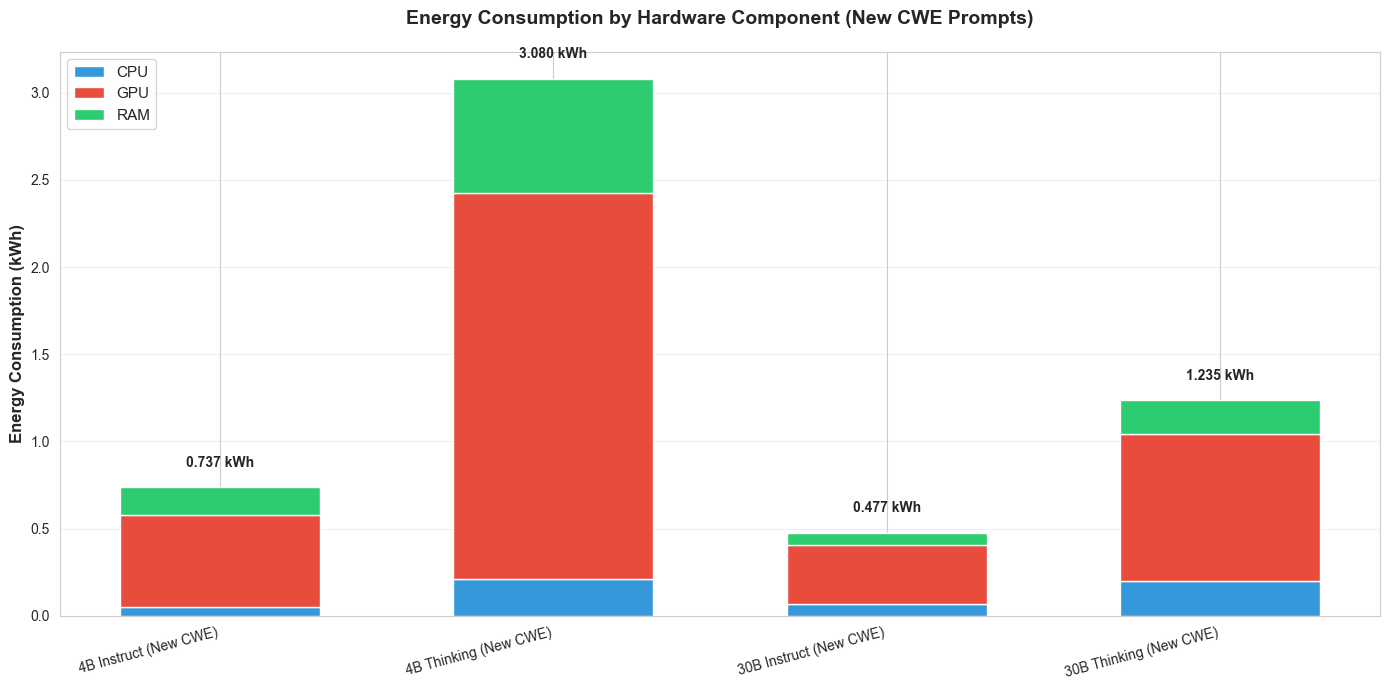

✓ Saved: ../results/analysis_prompt_comparison/codecarbon_energy_by_component.png


In [7]:
# Plot 1: Stacked bar chart of energy by component
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(hardware_df))
width = 0.6

# Stacked bars
colors = ['#3498db', '#e74c3c', '#2ecc71']
ax.bar(x, hardware_df['CPU Energy (kWh)'], width, label='CPU', color=colors[0])
ax.bar(x, hardware_df['GPU Energy (kWh)'], width, bottom=hardware_df['CPU Energy (kWh)'], 
       label='GPU', color=colors[1])
ax.bar(x, hardware_df['RAM Energy (kWh)'], width, 
       bottom=hardware_df['CPU Energy (kWh)'] + hardware_df['GPU Energy (kWh)'], 
       label='RAM', color=colors[2])

# Add total energy labels on top
for i, (idx, row) in enumerate(hardware_df.iterrows()):
    total = row['Total Energy (kWh)']
    ax.text(i, total + 0.1, f"{total:.3f} kWh", 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Energy Consumption (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Energy Consumption by Hardware Component (New CWE Prompts)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(hardware_df['Experiment'], rotation=15, ha='right')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codecarbon_energy_by_component.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'codecarbon_energy_by_component.png'}")

### 6.2 Power Consumption Comparison

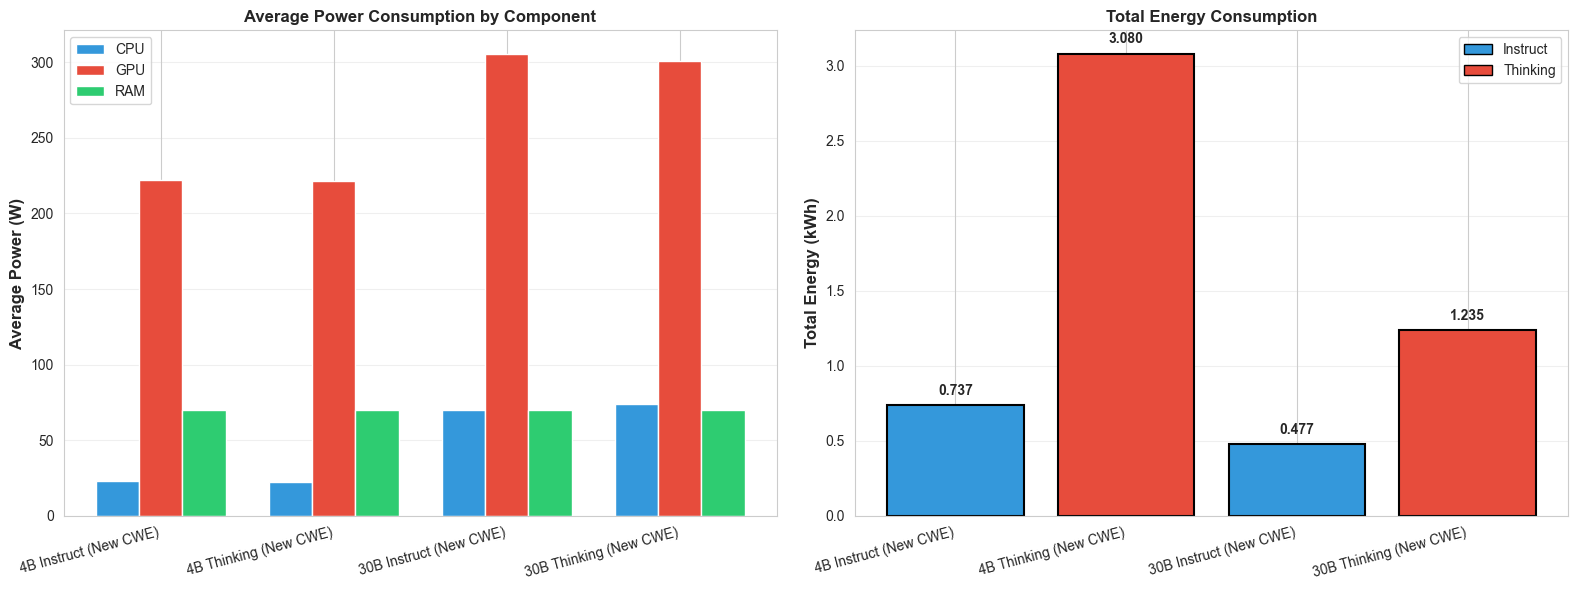

✓ Saved: ../results/analysis_prompt_comparison/codecarbon_power_consumption.png


In [8]:
# Plot 2: Power consumption comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(hardware_df))
width = 0.25

# Left: Average power by component
ax1.bar(x - width, hardware_df['Avg CPU Power (W)'], width, label='CPU', color=colors[0])
ax1.bar(x, hardware_df['Avg GPU Power (W)'], width, label='GPU', color=colors[1])
ax1.bar(x + width, hardware_df['Avg RAM Power (W)'], width, label='RAM', color=colors[2])

ax1.set_ylabel('Average Power (W)', fontsize=12, fontweight='bold')
ax1.set_title('Average Power Consumption by Component', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(hardware_df['Experiment'], rotation=15, ha='right')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Right: Total energy with model type coloring
model_colors = {'Instruct': '#3498db', 'Thinking': '#e74c3c'}
colors_map = [model_colors[m] for m in hardware_df['Model Type']]

bars = ax2.bar(x, hardware_df['Total Energy (kWh)'], color=colors_map, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, hardware_df['Total Energy (kWh)'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Total Energy (kWh)', fontsize=12, fontweight='bold')
ax2.set_title('Total Energy Consumption', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(hardware_df['Experiment'], rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add legend for model types
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Instruct'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Thinking')
]
ax2.legend(handles=legend_elements, fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codecarbon_power_consumption.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'codecarbon_power_consumption.png'}")

### 6.3 Energy Distribution Pie Charts

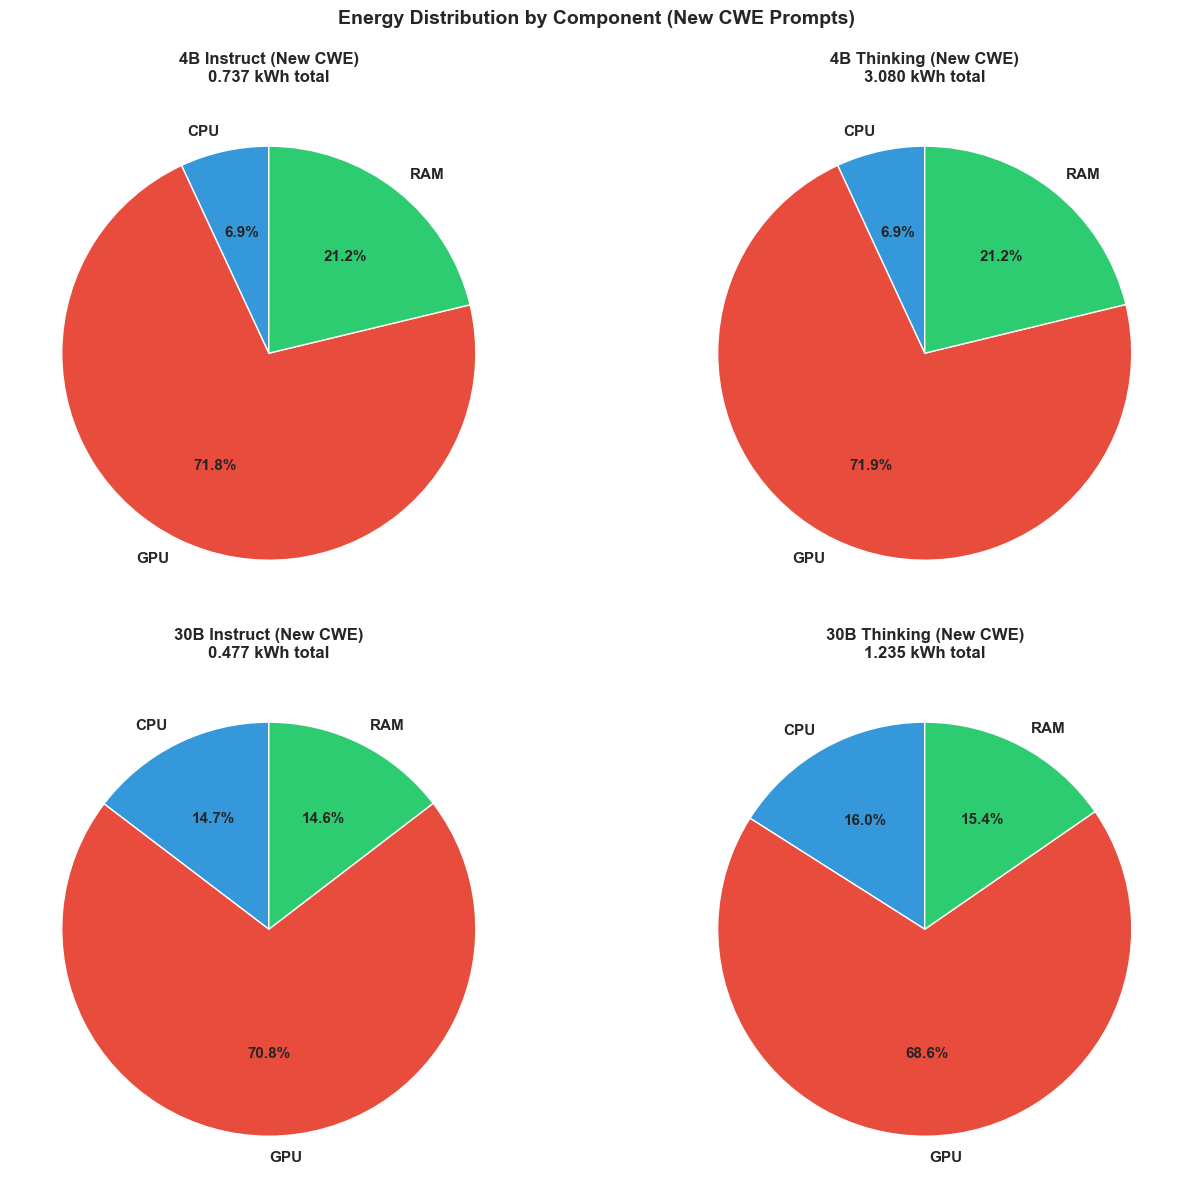

✓ Saved: ../results/analysis_prompt_comparison/codecarbon_energy_distribution_pies.png


In [9]:
# Plot 3: Pie charts showing energy distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

colors_pie = ['#3498db', '#e74c3c', '#2ecc71']

for idx, (_, row) in enumerate(hardware_df.iterrows()):
    energy_values = [
        row['CPU Energy (kWh)'],
        row['GPU Energy (kWh)'],
        row['RAM Energy (kWh)']
    ]
    
    axes[idx].pie(energy_values, labels=['CPU', 'GPU', 'RAM'], 
                 autopct='%1.1f%%', colors=colors_pie, startangle=90,
                 textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[idx].set_title(f"{row['Experiment']}\n{row['Total Energy (kWh)']:.3f} kWh total", 
                       fontsize=12, fontweight='bold', pad=10)

plt.suptitle('Energy Distribution by Component (New CWE Prompts)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codecarbon_energy_distribution_pies.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'codecarbon_energy_distribution_pies.png'}")

### 6.4 Model Size Comparison

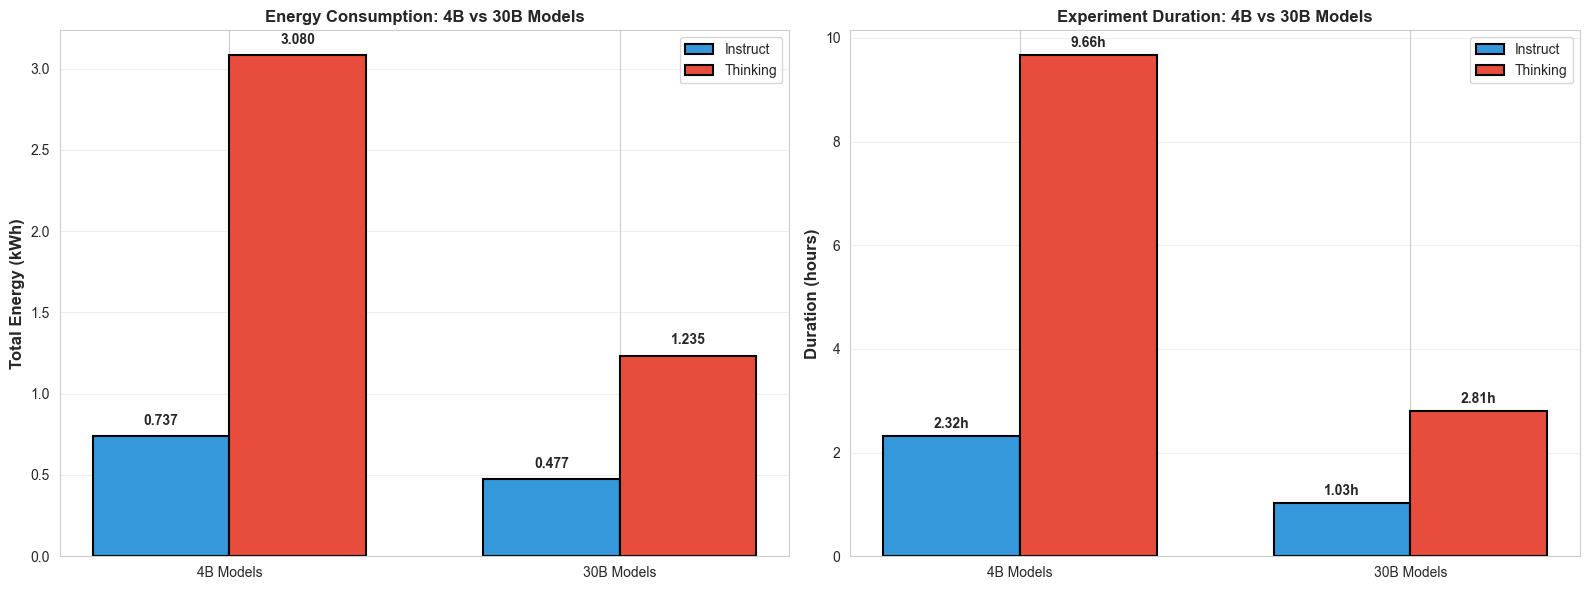

✓ Saved: ../results/analysis_prompt_comparison/codecarbon_model_size_comparison.png


In [10]:
# Plot 4: Compare 4B vs 30B energy efficiency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Group by model size
size_4b = hardware_df[hardware_df['Model Size'] == '4B']
size_30b = hardware_df[hardware_df['Model Size'] == '30B']

# Left: Energy by model size
x = np.arange(2)
width = 0.35

instruct_energy = [
    size_4b[size_4b['Model Type'] == 'Instruct']['Total Energy (kWh)'].values[0],
    size_30b[size_30b['Model Type'] == 'Instruct']['Total Energy (kWh)'].values[0]
]
thinking_energy = [
    size_4b[size_4b['Model Type'] == 'Thinking']['Total Energy (kWh)'].values[0],
    size_30b[size_30b['Model Type'] == 'Thinking']['Total Energy (kWh)'].values[0]
]

bars1 = ax1.bar(x - width/2, instruct_energy, width, label='Instruct', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, thinking_energy, width, label='Thinking', color='#e74c3c', edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Total Energy (kWh)', fontsize=12, fontweight='bold')
ax1.set_title('Energy Consumption: 4B vs 30B Models', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['4B Models', '30B Models'])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Right: Duration comparison
instruct_duration = [
    size_4b[size_4b['Model Type'] == 'Instruct']['Duration (hours)'].values[0],
    size_30b[size_30b['Model Type'] == 'Instruct']['Duration (hours)'].values[0]
]
thinking_duration = [
    size_4b[size_4b['Model Type'] == 'Thinking']['Duration (hours)'].values[0],
    size_30b[size_30b['Model Type'] == 'Thinking']['Duration (hours)'].values[0]
]

bars3 = ax2.bar(x - width/2, instruct_duration, width, label='Instruct', color='#3498db', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x + width/2, thinking_duration, width, label='Thinking', color='#e74c3c', edgecolor='black', linewidth=1.5)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{height:.2f}h', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Duration (hours)', fontsize=12, fontweight='bold')
ax2.set_title('Experiment Duration: 4B vs 30B Models', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['4B Models', '30B Models'])
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'codecarbon_model_size_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'codecarbon_model_size_comparison.png'}")

### 6.5 Comprehensive Energy-Performance Tradeoff (All Experiments)

Combines all 12 experiments:
- **Model sizes**: 4B and 30B  
- **Model types**: Instruct and Thinking  
- **Prompting**: Zero-shot and Few-shot  
- **Prompt versions**: Old (LLM-generated) and New (CWE-based)

Creating comprehensive energy-performance tradeoff scatter plot...
Total experiments to plot: 12
Model sizes: ['30B', '4B']
Prompt versions: ['New', 'Old']



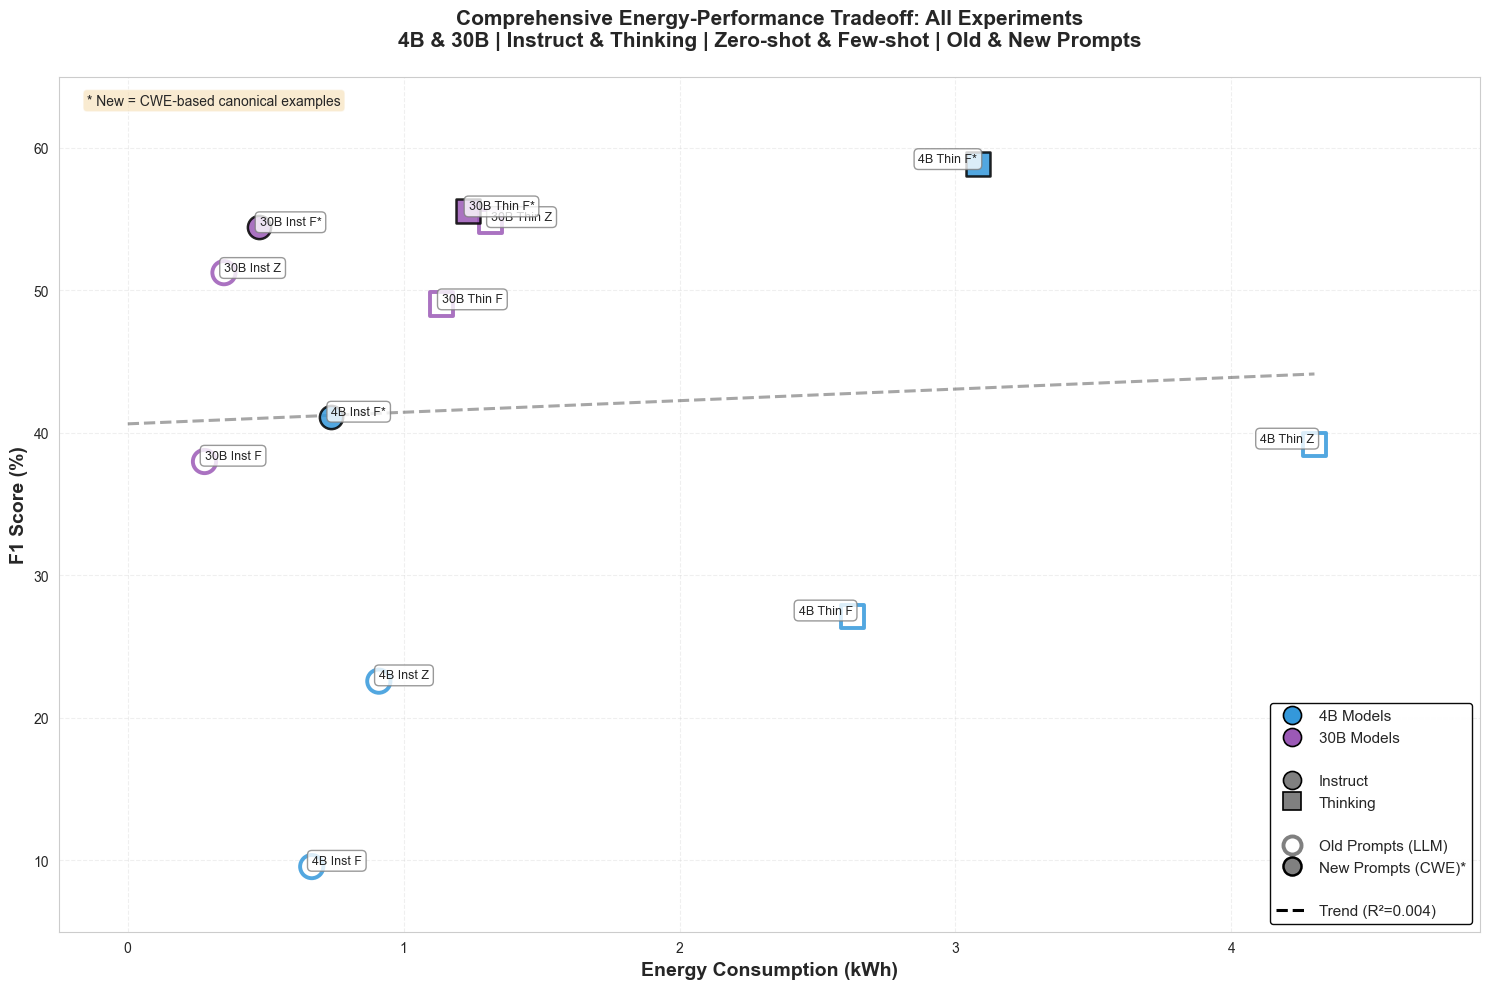


✓ Saved: ../results/analysis_prompt_comparison/comprehensive_energy_performance_tradeoff.png

Trendline Statistics:
  Slope: 0.8137 (F1% increase per kWh)
  Intercept: 40.63%
  R²: 0.0044
  p-value: 0.837638
  Correlation: Positive (Weak)


In [11]:
# Load OLD experiment data and create comprehensive scatter plot
print("Creating comprehensive energy-performance tradeoff scatter plot...")
print("=" * 80)

OLD_EXPERIMENTS = {
    '4b_instruct_zero': {'name': '4B Instruct Zero (Old)', 'f1': 0.2258, 'energy_kwh': 0.910080, 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot', 'prompt_version': 'Old'},
    '4b_instruct_few': {'name': '4B Instruct Few (Old)', 'f1': 0.0957, 'energy_kwh': 0.666897, 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'Old'},
    '4b_thinking_zero': {'name': '4B Thinking Zero (Old)', 'f1': 0.3919, 'energy_kwh': 4.301432, 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot', 'prompt_version': 'Old'},
    '4b_thinking_few': {'name': '4B Thinking Few (Old)', 'f1': 0.2713, 'energy_kwh': 2.628159, 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'Old'},
    '30b_instruct_zero': {'name': '30B Instruct Zero (Old)', 'f1': 0.5124, 'energy_kwh': 0.348762, 'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Zero-shot', 'prompt_version': 'Old'},
    '30b_instruct_few': {'name': '30B Instruct Few (Old)', 'f1': 0.3799, 'energy_kwh': 0.278148, 'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'Old'},
    '30b_thinking_zero': {'name': '30B Thinking Zero (Old)', 'f1': 0.5481, 'energy_kwh': 1.316173, 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot', 'prompt_version': 'Old'},
    '30b_thinking_few': {'name': '30B Thinking Few (Old)', 'f1': 0.4904, 'energy_kwh': 1.138116, 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'Old'}
}

NEW_EXPERIMENTS = {
    '4b_instruct_few': {'name': '4B Instruct Few (New)', 'f1': 0.4108, 'energy_kwh': hardware_df[hardware_df['Experiment'] == '4B Instruct (New CWE)']['Total Energy (kWh)'].values[0], 'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'New'},
    '4b_thinking_few': {'name': '4B Thinking Few (New)', 'f1': 0.5888, 'energy_kwh': hardware_df[hardware_df['Experiment'] == '4B Thinking (New CWE)']['Total Energy (kWh)'].values[0], 'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'New'},
    '30b_instruct_few': {'name': '30B Instruct Few (New)', 'f1': 0.5445, 'energy_kwh': hardware_df[hardware_df['Experiment'] == '30B Instruct (New CWE)']['Total Energy (kWh)'].values[0], 'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'New'},
    '30b_thinking_few': {'name': '30B Thinking Few (New)', 'f1': 0.5556, 'energy_kwh': hardware_df[hardware_df['Experiment'] == '30B Thinking (New CWE)']['Total Energy (kWh)'].values[0], 'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'New'}
}

# Combine all experiments
all_experiments = list(OLD_EXPERIMENTS.values()) + list(NEW_EXPERIMENTS.values())
all_exp_df = pd.DataFrame(all_experiments)

print(f"Total experiments to plot: {len(all_exp_df)}")
print(f"Model sizes: {sorted(all_exp_df['model_size'].unique())}")
print(f"Prompt versions: {sorted(all_exp_df['prompt_version'].unique())}")
print()

# Create scatter plot
from scipy import stats
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(15, 10))

# Define visual encoding
size_colors = {'4B': '#3498db', '30B': '#9b59b6'}
type_markers = {'Instruct': 'o', 'Thinking': 's'}

# Plot each experiment
for _, row in all_exp_df.iterrows():
    color = size_colors[row['model_size']]
    marker = type_markers[row['model_type']]
    
    if row['prompt_version'] == 'Old':
        ax.scatter(row['energy_kwh'], row['f1'] * 100, marker=marker, s=280, 
                  facecolors='none', edgecolors=color, linewidths=2.8, alpha=0.85, zorder=3)
    else:
        ax.scatter(row['energy_kwh'], row['f1'] * 100, marker=marker, s=280,
                  color=color, edgecolors='black', linewidths=1.8, alpha=0.85, zorder=3)
    
    # Add labels
    label_parts = row['name'].replace(' (Old)', '').replace(' (New)', '').split()
    short_label = f"{label_parts[0]} {label_parts[1][:4]} {label_parts[2][0]}"
    if row['prompt_version'] == 'New': short_label += "*"
    
    offset_x = 0.1 if row['energy_kwh'] < 2.5 else -0.18
    offset_y = 2.0 if row['f1'] < 0.45 else 1.2
    
    ax.annotate(short_label, (row['energy_kwh'], row['f1'] * 100),
               xytext=(offset_x, offset_y), textcoords='offset points',
               fontsize=9, ha='left' if offset_x > 0 else 'right',
               bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.8))

# Trendline
slope, intercept, r_value, p_value, std_err = stats.linregress(all_exp_df['energy_kwh'], all_exp_df['f1'] * 100)
x_trend = np.array([0, all_exp_df['energy_kwh'].max()])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, 'k--', alpha=0.35, linewidth=2.2, zorder=1)

# Formatting
ax.set_xlabel('Energy Consumption (kWh)', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Comprehensive Energy-Performance Tradeoff: All Experiments\n' + 
             '4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Old & New Prompts',
             fontsize=15, fontweight='bold', pad=22)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-0.25, all_exp_df['energy_kwh'].max() + 0.6)
ax.set_ylim(5, 65)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=13, label='4B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=13, label='30B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='Instruct', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=13, label='Thinking', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=13, label='Old Prompts (LLM)', markeredgecolor='gray', markeredgewidth=2.8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='New Prompts (CWE)*', markeredgecolor='black', markeredgewidth=1.8),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2, label=f'Trend (R²={r_value**2:.3f})')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.96, edgecolor='black', fancybox=True)
ax.text(0.02, 0.98, '* New = CWE-based canonical examples', transform=ax.transAxes, fontsize=10, 
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comprehensive_energy_performance_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {OUTPUT_DIR / 'comprehensive_energy_performance_tradeoff.png'}")
print(f"\nTrendline Statistics:")
print(f"  Slope: {slope:.4f} (F1% increase per kWh)")
print(f"  Intercept: {intercept:.2f}%")
print(f"  R²: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Correlation: {'Positive' if slope > 0 else 'Negative'} ({'Strong' if abs(r_value) > 0.7 else 'Moderate' if abs(r_value) > 0.4 else 'Weak'})")


## 7. Export Results

## 8. Classification Reports with Energy Metrics

This section creates sklearn-style classification reports showing per-class metrics (precision, recall, f1-score, support) combined with energy consumption data.

Covers:
- **Old prompts**: Phase 1 few-shot (4B) and Phase 2a few-shot (30B)
- **New prompts**: CWE-based canonical examples (4B and 30B few-shot)

In [12]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

def create_classification_report_with_energy(exp_name, file_path, total_energy_kwh, total_co2_kg):
    """
    Create a classification report table with energy metrics.
    
    Parameters:
    - exp_name: Experiment name
    - file_path: Path to detailed_results.jsonl
    - total_energy_kwh: Total energy consumption in kWh
    - total_co2_kg: Total CO2 emissions in kg
    
    Returns: DataFrame with classification report + energy metrics
    """
    # Load detailed results
    results = []
    with open(file_path, 'r') as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
    
    df = pd.DataFrame(results)
    
    # Filter valid samples
    if 'error' not in df.columns:
        df['error'] = ''
    df['error'] = df['error'].fillna('')
    valid_df = df[df['error'] == ''].copy()
    
    y_true = valid_df['ground_truth'].values
    y_pred = valid_df['vuln'].values
    
    # Calculate metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    accuracy = (y_true == y_pred).sum() / len(y_true)
    
    # Energy metrics
    total_samples = len(valid_df)
    energy_per_sample_kwh = total_energy_kwh / total_samples
    co2_per_sample_g = (total_co2_kg / total_samples) * 1000
    
    # Build report
    report_data = [
        {'class': 'Not Vulnerable', 'precision': precision[0], 'recall': recall[0], 'f1-score': f1[0], 
         'support': int(support[0]), 'energy/sample (kWh)': energy_per_sample_kwh, 'co2/sample (g)': co2_per_sample_g},
        {'class': 'Vulnerable', 'precision': precision[1], 'recall': recall[1], 'f1-score': f1[1],
         'support': int(support[1]), 'energy/sample (kWh)': energy_per_sample_kwh, 'co2/sample (g)': co2_per_sample_g},
        {'class': '', 'precision': np.nan, 'recall': np.nan, 'f1-score': np.nan, 'support': np.nan,
         'energy/sample (kWh)': np.nan, 'co2/sample (g)': np.nan},
        {'class': 'accuracy', 'precision': np.nan, 'recall': accuracy, 'f1-score': np.nan,
         'support': total_samples, 'energy/sample (kWh)': energy_per_sample_kwh, 'co2/sample (g)': co2_per_sample_g},
        {'class': 'macro avg', 'precision': precision_macro, 'recall': recall_macro, 'f1-score': f1_macro,
         'support': total_samples, 'energy/sample (kWh)': energy_per_sample_kwh, 'co2/sample (g)': co2_per_sample_g},
        {'class': 'weighted avg', 'precision': precision_weighted, 'recall': recall_weighted, 'f1-score': f1_weighted,
         'support': total_samples, 'energy/sample (kWh)': energy_per_sample_kwh, 'co2/sample (g)': co2_per_sample_g}
    ]
    
    report_df = pd.DataFrame(report_data).set_index('class')
    return report_df

print("Classification report helper function loaded")
print("=" * 80)

Classification report helper function loaded


### 8.1 Few-Shot with Old Prompts (LLM-Generated)

In [13]:
# Classification reports for OLD few-shot experiments
print("\n### OLD PROMPTS - FEW-SHOT EXPERIMENTS ###\n")

# Define RESULTS_BASE if needed
if 'RESULTS_BASE' not in dir():
    RESULTS_BASE = Path('../results')

# Old experiments with energy data
old_few_experiments = {
    '4B Instruct Few (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251011-102915_detailed_results.jsonl',
        'energy_kwh': 0.666897,
        'co2_kg': 0.11340120
    },
    '4B Thinking Few (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251011-103534_detailed_results.jsonl',
        'energy_kwh': 2.628159,
        'co2_kg': 0.44690007
    },
    '30B Instruct Few (Old)': {
        'file': RESULTS_BASE / 'runpod/instruct_few_20251020_200040/Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251020-111953_detailed_results.jsonl',
        'energy_kwh': 0.278148,
        'co2_kg': 0.04729710
    },
    '30B Thinking Few (Old)': {
        'file': RESULTS_BASE / 'runpod/thinking_few_20251020_214835/Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251020-111009_detailed_results.jsonl',
        'energy_kwh': 1.138116,
        'co2_kg': 0.19352871
    }
}

old_reports = {}
for exp_name, exp_config in old_few_experiments.items():
    if exp_config['file'].exists():
        report = create_classification_report_with_energy(
            exp_name,
            exp_config['file'],
            exp_config['energy_kwh'],
            exp_config['co2_kg']
        )
        old_reports[exp_name] = report
        print(f"{exp_name}:")
        print(report.to_string())
        print("\n")
    else:
        print(f"⚠️  {exp_name}: File not found")


### OLD PROMPTS - FEW-SHOT EXPERIMENTS ###



NameError: name 'RESULTS_BASE' is not defined

### 8.2 Few-Shot with New CWE Prompts

In [ ]:
# Classification reports for NEW CWE few-shot experiments
print("\n### NEW CWE PROMPTS - FEW-SHOT EXPERIMENTS ###\n")

# Map experiment names to file paths and energy data
new_few_experiments = {
    '4B Instruct Few (New)': {
        'file': RESULTS_BASE / 'mars_rerun/Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251101-200224_detailed_results.jsonl',
        'energy_kwh': hardware_df[hardware_df['Experiment'] == '4B Instruct (New CWE)']['Total Energy (kWh)'].values[0],
        'co2_kg': hardware_df[hardware_df['Experiment'] == '4B Instruct (New CWE)']['Total CO2 (kg)'].values[0]
    },
    '4B Thinking Few (New)': {
        'file': RESULTS_BASE / 'mars_rerun/Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251101-200857_detailed_results.jsonl',
        'energy_kwh': hardware_df[hardware_df['Experiment'] == '4B Thinking (New CWE)']['Total Energy (kWh)'].values[0],
        'co2_kg': hardware_df[hardware_df['Experiment'] == '4B Thinking (New CWE)']['Total CO2 (kg)'].values[0]
    },
    '30B Instruct Few (New)': {
        'file': RESULTS_BASE / 'runpod_rerun/Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251102-042208_detailed_results.jsonl',
        'energy_kwh': hardware_df[hardware_df['Experiment'] == '30B Instruct (New CWE)']['Total Energy (kWh)'].values[0],
        'co2_kg': hardware_df[hardware_df['Experiment'] == '30B Instruct (New CWE)']['Total CO2 (kg)'].values[0]
    },
    '30B Thinking Few (New)': {
        'file': RESULTS_BASE / 'runpod_rerun/Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251102-042248_detailed_results.jsonl',
        'energy_kwh': hardware_df[hardware_df['Experiment'] == '30B Thinking (New CWE)']['Total Energy (kWh)'].values[0],
        'co2_kg': hardware_df[hardware_df['Experiment'] == '30B Thinking (New CWE)']['Total CO2 (kg)'].values[0]
    }
}

new_reports = {}
for exp_name, exp_config in new_few_experiments.items():
    if exp_config['file'].exists():
        report = create_classification_report_with_energy(
            exp_name,
            exp_config['file'],
            exp_config['energy_kwh'],
            exp_config['co2_kg']
        )
        new_reports[exp_name] = report
        print(f"{exp_name}:")
        print(report.to_string())
        print("\n")
    else:
        print(f"⚠️  {exp_name}: File not found")

### 8.3 Export Classification Reports to Excel

In [ ]:
# Export all classification reports to Excel
with pd.ExcelWriter(OUTPUT_DIR / 'prompt_comparison_classification_reports.xlsx') as writer:
    # Old prompts
    for exp_name, report in old_reports.items():
        sheet_name = exp_name.replace(' (Old)', ' Old')
        report.to_excel(writer, sheet_name=sheet_name)
    
    # New prompts
    for exp_name, report in new_reports.items():
        sheet_name = exp_name.replace(' (New)', ' New')
        report.to_excel(writer, sheet_name=sheet_name)
    
    # Summary comparison: Old vs New
    summary_data = []
    for exp_name in ['4B Instruct Few', '4B Thinking Few', '30B Instruct Few', '30B Thinking Few']:
        old_key = f"{exp_name} (Old)"
        new_key = f"{exp_name} (New)"
        
        if old_key in old_reports and new_key in new_reports:
            old_report = old_reports[old_key]
            new_report = new_reports[new_key]
            
            summary_data.append({
                'Experiment': exp_name,
                'Old F1 (Vulnerable)': old_report.loc['Vulnerable', 'f1-score'],
                'New F1 (Vulnerable)': new_report.loc['Vulnerable', 'f1-score'],
                'F1 Improvement': new_report.loc['Vulnerable', 'f1-score'] - old_report.loc['Vulnerable', 'f1-score'],
                'Old Accuracy': old_report.loc['accuracy', 'recall'],
                'New Accuracy': new_report.loc['accuracy', 'recall'],
                'Old Energy/Sample (kWh)': old_report.loc['accuracy', 'energy/sample (kWh)'],
                'New Energy/Sample (kWh)': new_report.loc['accuracy', 'energy/sample (kWh)'],
                'Old CO2/Sample (g)': old_report.loc['accuracy', 'co2/sample (g)'],
                'New CO2/Sample (g)': new_report.loc['accuracy', 'co2/sample (g)']
            })
    
    summary_df = pd.DataFrame(summary_data)
    summary_df.to_excel(writer, sheet_name='Old vs New Comparison', index=False)

print(f"✓ Classification reports exported to {OUTPUT_DIR / 'prompt_comparison_classification_reports.xlsx'}")
print(f"  Total sheets: {len(old_reports) + len(new_reports) + 1}")
print(f"  Old prompts: {len(old_reports)} experiments")
print(f"  New prompts: {len(new_reports)} experiments")
print(f"  Summary: Old vs New comparison")

### 8.4 Visualization: Old vs New Prompts Comparison

In [ ]:
# Create comparison visualization: F1 scores and Energy consumption
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

experiments_list = ['4B Instruct\nFew', '4B Thinking\nFew', '30B Instruct\nFew', '30B Thinking\nFew']

# Collect F1 and energy data
old_f1 = []
new_f1 = []
old_energy = []
new_energy = []

for exp_base in ['4B Instruct Few', '4B Thinking Few', '30B Instruct Few', '30B Thinking Few']:
    old_key = f"{exp_base} (Old)"
    new_key = f"{exp_base} (New)"
    
    if old_key in old_reports:
        old_f1.append(old_reports[old_key].loc['Vulnerable', 'f1-score'])
        old_energy.append(old_reports[old_key].loc['accuracy', 'energy/sample (kWh)'])
    else:
        old_f1.append(0)
        old_energy.append(0)
    
    if new_key in new_reports:
        new_f1.append(new_reports[new_key].loc['Vulnerable', 'f1-score'])
        new_energy.append(new_reports[new_key].loc['accuracy', 'energy/sample (kWh)'])
    else:
        new_f1.append(0)
        new_energy.append(0)

x = np.arange(len(experiments_list))
width = 0.35

# Left: F1 Score comparison
bars1 = ax1.bar(x - width/2, old_f1, width, label='Old Prompts (LLM)', color='#95a5a6', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, new_f1, width, label='New Prompts (CWE)', color='#27ae60', edgecolor='black', linewidth=1.5)

# Add value labels and improvement arrows
for i, (old_val, new_val) in enumerate(zip(old_f1, new_f1)):
    if old_val > 0:
        ax1.text(i - width/2, old_val + 0.015, f'{old_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    if new_val > 0:
        ax1.text(i + width/2, new_val + 0.015, f'{new_val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Draw improvement arrow
    if old_val > 0 and new_val > 0 and new_val > old_val:
        improvement_pct = ((new_val - old_val) / old_val) * 100
        arrow_y = max(old_val, new_val) + 0.05
        ax1.annotate('', xy=(i + width/2, arrow_y - 0.02), xytext=(i - width/2, arrow_y - 0.02),
                    arrowprops=dict(arrowstyle='->', lw=2, color='green'))
        ax1.text(i, arrow_y, f'+{improvement_pct:.1f}%', ha='center', va='bottom', 
                fontsize=9, fontweight='bold', color='green')

ax1.set_ylabel('Vulnerable Class F1-Score', fontsize=12, fontweight='bold')
ax1.set_title('Vulnerable Class F1-Score: Old vs New Prompts', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(experiments_list)
ax1.set_ylim([0, max(max(old_f1), max(new_f1)) * 1.25])
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Right: Energy per sample comparison
bars3 = ax2.bar(x - width/2, old_energy, width, label='Old Prompts (LLM)', color='#95a5a6', edgecolor='black', linewidth=1.5)
bars4 = ax2.bar(x + width/2, new_energy, width, label='New Prompts (CWE)', color='#27ae60', edgecolor='black', linewidth=1.5)

# Add value labels
for i, (old_val, new_val) in enumerate(zip(old_energy, new_energy)):
    if old_val > 0:
        ax2.text(i - width/2, old_val + 0.0001, f'{old_val:.6f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    if new_val > 0:
        ax2.text(i + width/2, new_val + 0.0001, f'{new_val:.6f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_ylabel('Energy per Sample (kWh)', fontsize=12, fontweight='bold')
ax2.set_title('Energy Consumption per Sample: Old vs New Prompts', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(experiments_list)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'prompt_comparison_classification_f1_energy.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'prompt_comparison_classification_f1_energy.png'}")

## 9. Token Usage Analysis

Analyze output token lengths from all vulnerability detection experiments to evaluate the relevance and efficiency of model outputs relative to energy consumption.

In [ ]:
def estimate_tokens(text):
    """
    Estimate token count from character count.
    Conservative estimate: ~3.5 chars per token for code/reasoning text.
    """
    if not text:
        return 0
    chars = len(text)
    estimated_tokens = chars / 3.5
    return int(estimated_tokens)

def analyze_detailed_results(file_path):
    """Analyze token usage from a detailed results JSONL file"""
    stats = {
        'total_samples': 0,
        'total_reasoning_chars': 0,
        'total_reasoning_tokens': 0,
        'reasoning_lengths_tokens': [],
        'reasoning_lengths_chars': [],
        'samples_with_reasoning': 0
    }
    
    if not file_path.exists():
        return stats
    
    with open(file_path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            stats['total_samples'] += 1
            
            try:
                record = json.loads(line)
                if 'reasoning' in record and record['reasoning']:
                    reasoning_text = record['reasoning']
                    chars = len(reasoning_text)
                    tokens = estimate_tokens(reasoning_text)
                    
                    stats['total_reasoning_chars'] += chars
                    stats['total_reasoning_tokens'] += tokens
                    stats['reasoning_lengths_tokens'].append(tokens)
                    stats['reasoning_lengths_chars'].append(chars)
                    stats['samples_with_reasoning'] += 1
            except (json.JSONDecodeError, KeyError):
                continue
    
    # Calculate statistics
    if stats['reasoning_lengths_tokens']:
        stats['avg_tokens_per_sample'] = stats['total_reasoning_tokens'] / stats['samples_with_reasoning']
        stats['min_tokens'] = min(stats['reasoning_lengths_tokens'])
        stats['max_tokens'] = max(stats['reasoning_lengths_tokens'])
        stats['median_tokens'] = np.median(stats['reasoning_lengths_tokens'])
        stats['std_tokens'] = np.std(stats['reasoning_lengths_tokens'])
    else:
        stats['avg_tokens_per_sample'] = 0
        stats['min_tokens'] = 0
        stats['max_tokens'] = 0
        stats['median_tokens'] = 0
        stats['std_tokens'] = 0
    
    return stats

print("Token analysis helper functions loaded")

In [ ]:
# Configure all experiment paths for token analysis
RESULTS_BASE = Path('../results')

TOKEN_ANALYSIS_EXPERIMENTS = {
    # OLD Phase 1 - 4B Models (Mars)
    '4B Instruct Zero (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-zero_Qwen-Qwen3-4B-Instruct-2507_20251011-083716_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Zero-shot', 'prompt_version': 'Old'
    },
    '4B Instruct Few (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251011-102915_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'Old'
    },
    '4B Thinking Zero (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-zero_Qwen-Qwen3-4B-Thinking-2507_20251011-083616_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Zero-shot', 'prompt_version': 'Old'
    },
    '4B Thinking Few (Old)': {
        'file': RESULTS_BASE / 'mars/Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251011-103534_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'Old'
    },
    
    # OLD Phase 2a - 30B Models (RunPod)
    '30B Instruct Zero (Old)': {
        'file': RESULTS_BASE / 'runpod/instruct_zero_20251020_194844/Sa-zero_Qwen-Qwen3-30B-A3B-Instruct-2507_20251020-104948_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Zero-shot', 'prompt_version': 'Old'
    },
    '30B Instruct Few (Old)': {
        'file': RESULTS_BASE / 'runpod/instruct_few_20251020_200040/Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251020-111953_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'Old'
    },
    '30B Thinking Zero (Old)': {
        'file': RESULTS_BASE / 'runpod/thinking_zero_20251020_215332/Sa-zero_Qwen-Qwen3-30B-A3B-Thinking-2507_20251020-104530_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Zero-shot', 'prompt_version': 'Old'
    },
    '30B Thinking Few (Old)': {
        'file': RESULTS_BASE / 'runpod/thinking_few_20251020_214835/Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251020-111009_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'Old'
    },
    
    # NEW Re-runs - Few-shot with CWE prompts
    '4B Instruct Few (New)': {
        'file': RESULTS_BASE / 'mars_rerun/Sa-few_Qwen-Qwen3-4B-Instruct-2507_20251101-200224_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'New'
    },
    '4B Thinking Few (New)': {
        'file': RESULTS_BASE / 'mars_rerun/Sa-few_Qwen-Qwen3-4B-Thinking-2507_20251101-200857_detailed_results.jsonl',
        'model_size': '4B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'New'
    },
    '30B Instruct Few (New)': {
        'file': RESULTS_BASE / 'runpod_rerun/Sa-few_Qwen-Qwen3-30B-A3B-Instruct-2507_20251102-042208_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Instruct', 'prompting': 'Few-shot', 'prompt_version': 'New'
    },
    '30B Thinking Few (New)': {
        'file': RESULTS_BASE / 'runpod_rerun/Sa-few_Qwen-Qwen3-30B-A3B-Thinking-2507_20251102-042248_detailed_results.jsonl',
        'model_size': '30B', 'model_type': 'Thinking', 'prompting': 'Few-shot', 'prompt_version': 'New'
    }
}

print(f"Configured {len(TOKEN_ANALYSIS_EXPERIMENTS)} experiments for token analysis")
print(f"\nBreakdown:")
print(f"  Old experiments: {sum(1 for v in TOKEN_ANALYSIS_EXPERIMENTS.values() if v['prompt_version'] == 'Old')}")
print(f"  New experiments: {sum(1 for v in TOKEN_ANALYSIS_EXPERIMENTS.values() if v['prompt_version'] == 'New')}")

In [ ]:
# Analyze token usage for all experiments
print("=" * 120)
print("TOKEN USAGE ANALYSIS - All Vulnerability Detection Experiments")
print("=" * 120)
print()

token_stats_list = []

for exp_name, exp_config in TOKEN_ANALYSIS_EXPERIMENTS.items():
    file_path = exp_config['file']
    
    if not file_path.exists():
        print(f"⚠️  {exp_name}: File not found - {file_path}")
        continue
    
    stats = analyze_detailed_results(file_path)
    
    # Add metadata
    stats['experiment'] = exp_name
    stats['model_size'] = exp_config['model_size']
    stats['model_type'] = exp_config['model_type']
    stats['prompting'] = exp_config['prompting']
    stats['prompt_version'] = exp_config['prompt_version']
    
    token_stats_list.append(stats)
    
    print(f"{exp_name}:")
    print(f"  Samples: {stats['total_samples']}")
    print(f"  Samples with output: {stats['samples_with_reasoning']}")
    print(f"  Total output tokens (est): {stats['total_reasoning_tokens']:,}")
    print(f"  Avg tokens/sample: {stats['avg_tokens_per_sample']:.0f}")
    print(f"  Median tokens: {stats['median_tokens']:.0f}")
    print(f"  Min-Max tokens: {stats['min_tokens']}-{stats['max_tokens']}")
    print()

# Create DataFrame
token_df = pd.DataFrame(token_stats_list)

print("=" * 120)
print(f"✓ Analyzed {len(token_df)} experiments")
print("=" * 120)
token_df[['experiment', 'model_size', 'model_type', 'prompting', 'prompt_version', 
          'total_samples', 'total_reasoning_tokens', 'avg_tokens_per_sample']]

### 9.1 Token Usage Visualizations

In [ ]:
# Plot 1: Average tokens per sample - comparison across all experiments
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Left: Bar chart by experiment
x = np.arange(len(token_df))
colors_token = ['#3498db' if 'Instruct' in exp else '#e74c3c' for exp in token_df['experiment']]

bars = ax1.bar(x, token_df['avg_tokens_per_sample'], color=colors_token, edgecolor='black', linewidth=1.2)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, token_df['avg_tokens_per_sample'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_ylabel('Average Output Tokens per Sample', fontsize=12, fontweight='bold')
ax1.set_title('Average Output Token Usage by Experiment', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([exp.replace(' (Old)', '\n(Old)').replace(' (New)', '\n(New)') for exp in token_df['experiment']], 
                      rotation=45, ha='right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3498db', edgecolor='black', label='Instruct'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Thinking')
]
ax1.legend(handles=legend_elements, fontsize=10, loc='upper left')

# Right: Grouped by model type
model_types = ['4B Instruct', '4B Thinking', '30B Instruct', '30B Thinking']
old_tokens = []
new_tokens = []

for model_type in model_types:
    size, mtype = model_type.split()
    old_few = token_df[(token_df['model_size'] == size) & 
                       (token_df['model_type'] == mtype) & 
                       (token_df['prompting'] == 'Few-shot') & 
                       (token_df['prompt_version'] == 'Old')]
    new_few = token_df[(token_df['model_size'] == size) & 
                       (token_df['model_type'] == mtype) & 
                       (token_df['prompting'] == 'Few-shot') & 
                       (token_df['prompt_version'] == 'New')]
    
    old_tokens.append(old_few['avg_tokens_per_sample'].values[0] if len(old_few) > 0 else 0)
    new_tokens.append(new_few['avg_tokens_per_sample'].values[0] if len(new_few) > 0 else 0)

x2 = np.arange(len(model_types))
width = 0.35

bars1 = ax2.bar(x2 - width/2, old_tokens, width, label='Old Prompts', color='#95a5a6', edgecolor='black', linewidth=1.2)
bars2 = ax2.bar(x2 + width/2, new_tokens, width, label='New Prompts (CWE)', color='#27ae60', edgecolor='black', linewidth=1.2)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height + 15,
                    f'{height:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Average Output Tokens per Sample', fontsize=12, fontweight='bold')
ax2.set_title('Token Usage: Old vs New Prompts (Few-shot)', fontsize=13, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(model_types)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'token_usage_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'token_usage_comparison.png'}")

In [ ]:
# Merge token data with energy data for few-shot new prompts
token_energy_comparison = []

for _, row in hardware_df.iterrows():
    exp_name_map = {
        '4B Instruct (New CWE)': '4B Instruct Few (New)',
        '4B Thinking (New CWE)': '4B Thinking Few (New)',
        '30B Instruct (New CWE)': '30B Instruct Few (New)',
        '30B Thinking (New CWE)': '30B Thinking Few (New)'
    }
    
    token_exp_name = exp_name_map.get(row['Experiment'])
    if token_exp_name:
        token_data = token_df[token_df['experiment'] == token_exp_name].iloc[0]
        
        token_energy_comparison.append({
            'Experiment': row['Experiment'].replace(' (New CWE)', ''),
            'Model Size': row['Model Size'],
            'Model Type': row['Model Type'],
            'Total Energy (kWh)': row['Total Energy (kWh)'],
            'Duration (hours)': row['Duration (hours)'],
            'Avg Tokens/Sample': token_data['avg_tokens_per_sample'],
            'Total Tokens': token_data['total_reasoning_tokens'],
            'Tokens per kWh': token_data['total_reasoning_tokens'] / row['Total Energy (kWh)'],
            'Energy per 1K Tokens (Wh)': (row['Total Energy (kWh)'] * 1000) / (token_data['total_reasoning_tokens'] / 1000)
        })

token_energy_df = pd.DataFrame(token_energy_comparison)

print("Token & Energy Efficiency Metrics (New CWE Prompts):")
print("=" * 120)
token_energy_df

In [ ]:
# Plot 2: Token Length vs Energy Consumption Scatter Plot
print("Creating Token Length vs Energy Consumption scatter plot...")
print("=" * 80)

# Prepare data - include ALL experiments (Old + New)
scatter_data = []

# OLD experiments energy map
energy_map = {
    '4B Instruct Zero (Old)': 0.910080,
    '4B Instruct Few (Old)': 0.666897,
    '4B Thinking Zero (Old)': 4.301432,
    '4B Thinking Few (Old)': 2.628159,
    '30B Instruct Zero (Old)': 0.348762,
    '30B Instruct Few (Old)': 0.278148,
    '30B Thinking Zero (Old)': 1.316173,
    '30B Thinking Few (Old)': 1.138116
}

# Add OLD experiments
for exp_name in TOKEN_ANALYSIS_EXPERIMENTS.keys():
    if 'Old' in exp_name:
        token_stats = token_df[token_df['experiment'] == exp_name]
        if len(token_stats) > 0:
            token_stat = token_stats.iloc[0]
            energy_kwh = energy_map.get(exp_name)
            if energy_kwh:
                scatter_data.append({
                    'experiment': exp_name,
                    'model_size': token_stat['model_size'],
                    'model_type': token_stat['model_type'],
                    'prompting': token_stat['prompting'],
                    'prompt_version': 'Old',
                    'avg_tokens': token_stat['avg_tokens_per_sample'],
                    'energy_kwh': energy_kwh
                })

# Add NEW experiments
for _, row in token_energy_df.iterrows():
    exp_name_map = {
        '4B Instruct': '4B Instruct Few (New)',
        '4B Thinking': '4B Thinking Few (New)',
        '30B Instruct': '30B Instruct Few (New)',
        '30B Thinking': '30B Thinking Few (New)'
    }
    
    new_exp_name = exp_name_map.get(row['Experiment'])
    if new_exp_name:
        scatter_data.append({
            'experiment': new_exp_name,
            'model_size': row['Model Size'],
            'model_type': row['Model Type'],
            'prompting': 'Few-shot',
            'prompt_version': 'New',
            'avg_tokens': row['Avg Tokens/Sample'],
            'energy_kwh': row['Total Energy (kWh)']
        })

scatter_df = pd.DataFrame(scatter_data)

print(f"Total experiments: {len(scatter_df)}")

# Create scatter plot
from scipy import stats
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(15, 10))

size_colors = {'4B': '#3498db', '30B': '#9b59b6'}
type_markers = {'Instruct': 'o', 'Thinking': 's'}

# Plot each point
for _, row in scatter_df.iterrows():
    color = size_colors[row['model_size']]
    marker = type_markers[row['model_type']]
    
    if row['prompt_version'] == 'Old':
        ax.scatter(row['energy_kwh'], row['avg_tokens'], marker=marker, s=280, 
                  facecolors='none', edgecolors=color, linewidths=2.8, alpha=0.85, zorder=3)
    else:
        ax.scatter(row['energy_kwh'], row['avg_tokens'], marker=marker, s=280,
                  color=color, edgecolors='black', linewidths=1.8, alpha=0.85, zorder=3)
    
    # Labels
    label_parts = row['experiment'].replace(' (Old)', '').replace(' (New)', '').split()
    short_label = f"{label_parts[0]} {label_parts[1][:4]}"
    if len(label_parts) >= 3:
        short_label += f" {label_parts[2][0]}"
    if row['prompt_version'] == 'New': 
        short_label += "*"
    
    offset_x = 0.1 if row['energy_kwh'] < 2.5 else -0.15
    offset_y = 20 if row['avg_tokens'] < 600 else 15
    
    ax.annotate(short_label, (row['energy_kwh'], row['avg_tokens']),
               xytext=(offset_x, offset_y), textcoords='offset points',
               fontsize=9, ha='left' if offset_x > 0 else 'right',
               bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.8))

# Trendline
slope, intercept, r_value, p_value, std_err = stats.linregress(scatter_df['energy_kwh'], scatter_df['avg_tokens'])
x_trend = np.array([0, scatter_df['energy_kwh'].max()])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, 'k--', alpha=0.35, linewidth=2.2, zorder=1)

# Formatting
ax.set_xlabel('Energy Consumption (kWh)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Output Tokens per Sample', fontsize=14, fontweight='bold')
ax.set_title('Token Length vs Energy Consumption: All Experiments\n' + 
             '4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Old & New Prompts',
             fontsize=15, fontweight='bold', pad=22)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-0.25, scatter_df['energy_kwh'].max() + 0.6)
ax.set_ylim(100, scatter_df['avg_tokens'].max() + 100)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=13, label='4B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=13, label='30B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='Instruct', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=13, label='Thinking', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=13, label='Old Prompts (LLM)', markeredgecolor='gray', markeredgewidth=2.8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='New Prompts (CWE)*', markeredgecolor='black', markeredgewidth=1.8),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2, label=f'Trend (R²={r_value**2:.3f})')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.96, edgecolor='black', fancybox=True)
ax.text(0.02, 0.98, '* New = CWE-based canonical examples', transform=ax.transAxes, fontsize=10, 
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'token_vs_energy_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {OUTPUT_DIR / 'token_vs_energy_scatter.png'}")
print(f"\nTrendline: slope={slope:.2f}, R²={r_value**2:.4f}")

In [ ]:
# Plot 3: Token Length vs F1 Score Scatter Plot
print("Creating Token Length vs F1 Score scatter plot...")
print("=" * 80)

# Prepare data with F1 scores
f1_scatter_data = []

# F1 scores map
f1_map = {
    '4B Instruct Zero (Old)': 0.2258,
    '4B Instruct Few (Old)': 0.0957,
    '4B Thinking Zero (Old)': 0.3919,
    '4B Thinking Few (Old)': 0.2713,
    '30B Instruct Zero (Old)': 0.5124,
    '30B Instruct Few (Old)': 0.3799,
    '30B Thinking Zero (Old)': 0.5481,
    '30B Thinking Few (Old)': 0.4904
}

# Add OLD experiments
for _, token_stat in token_df[token_df['prompt_version'] == 'Old'].iterrows():
    exp_name = token_stat['experiment']
    f1_score = f1_map.get(exp_name)
    if f1_score:
        f1_scatter_data.append({
            'experiment': exp_name,
            'model_size': token_stat['model_size'],
            'model_type': token_stat['model_type'],
            'prompting': token_stat['prompting'],
            'prompt_version': 'Old',
            'avg_tokens': token_stat['avg_tokens_per_sample'],
            'f1': f1_score
        })

# Add NEW experiments with F1 scores
new_f1_map = {
    '4B Instruct Few (New)': 0.4108,
    '4B Thinking Few (New)': 0.5888,
    '30B Instruct Few (New)': 0.5445,
    '30B Thinking Few (New)': 0.5556
}

for _, token_stat in token_df[token_df['prompt_version'] == 'New'].iterrows():
    exp_name = token_stat['experiment']
    f1_score = new_f1_map.get(exp_name)
    if f1_score:
        f1_scatter_data.append({
            'experiment': exp_name,
            'model_size': token_stat['model_size'],
            'model_type': token_stat['model_type'],
            'prompting': token_stat['prompting'],
            'prompt_version': 'New',
            'avg_tokens': token_stat['avg_tokens_per_sample'],
            'f1': f1_score
        })

f1_scatter_df = pd.DataFrame(f1_scatter_data)

print(f"Total experiments: {len(f1_scatter_df)}")

# Create scatter plot
from scipy import stats
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(15, 10))

size_colors = {'4B': '#3498db', '30B': '#9b59b6'}
type_markers = {'Instruct': 'o', 'Thinking': 's'}

# Plot points
for _, row in f1_scatter_df.iterrows():
    color = size_colors[row['model_size']]
    marker = type_markers[row['model_type']]
    
    if row['prompt_version'] == 'Old':
        ax.scatter(row['avg_tokens'], row['f1'] * 100, marker=marker, s=280, 
                  facecolors='none', edgecolors=color, linewidths=2.8, alpha=0.85, zorder=3)
    else:
        ax.scatter(row['avg_tokens'], row['f1'] * 100, marker=marker, s=280,
                  color=color, edgecolors='black', linewidths=1.8, alpha=0.85, zorder=3)
    
    label_parts = row['experiment'].replace(' (Old)', '').replace(' (New)', '').split()
    short_label = f"{label_parts[0]} {label_parts[1][:4]}"
    if len(label_parts) >= 3:
        short_label += f" {label_parts[2][0]}"
    if row['prompt_version'] == 'New': 
        short_label += "*"
    
    offset_x = 20 if row['avg_tokens'] < 500 else -20
    offset_y = 2.0 if row['f1'] < 0.45 else 1.2
    
    ax.annotate(short_label, (row['avg_tokens'], row['f1'] * 100),
               xytext=(offset_x, offset_y), textcoords='offset points',
               fontsize=9, ha='left' if offset_x > 0 else 'right',
               bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='gray', alpha=0.8))

# Trendline
slope, intercept, r_value, p_value, std_err = stats.linregress(f1_scatter_df['avg_tokens'], f1_scatter_df['f1'] * 100)
x_trend = np.array([f1_scatter_df['avg_tokens'].min() - 50, f1_scatter_df['avg_tokens'].max() + 50])
y_trend = slope * x_trend + intercept
ax.plot(x_trend, y_trend, 'k--', alpha=0.35, linewidth=2.2, zorder=1)

# Formatting
ax.set_xlabel('Average Output Tokens per Sample', fontsize=14, fontweight='bold')
ax.set_ylabel('F1 Score (%)', fontsize=14, fontweight='bold')
ax.set_title('Token Length vs Performance: All Experiments\n' + 
             '4B & 30B | Instruct & Thinking | Zero-shot & Few-shot | Old & New Prompts',
             fontsize=15, fontweight='bold', pad=22)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(f1_scatter_df['avg_tokens'].min() - 100, f1_scatter_df['avg_tokens'].max() + 100)
ax.set_ylim(5, 65)

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=13, label='4B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=13, label='30B Models', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='Instruct', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=13, label='Thinking', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=13, label='Old Prompts (LLM)', markeredgecolor='gray', markeredgewidth=2.8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=13, label='New Prompts (CWE)*', markeredgecolor='black', markeredgewidth=1.8),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2.2, label=f'Trend (R²={r_value**2:.3f})')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.96, edgecolor='black', fancybox=True)
ax.text(0.02, 0.98, '* New = CWE-based canonical examples', transform=ax.transAxes, fontsize=10,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'token_vs_f1_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {OUTPUT_DIR / 'token_vs_f1_scatter.png'}")
print(f"\nTrendline Statistics:")
print(f"  Slope: {slope:.4f} (F1% increase per token)")
print(f"  Intercept: {intercept:.2f}%")
print(f"  R²: {r_value**2:.4f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Correlation: {'Positive' if slope > 0 else 'Negative'} ({'Strong' if abs(r_value) > 0.7 else 'Moderate' if abs(r_value) > 0.4 else 'Weak'}")
print()
if slope > 0:
    print("Interpretation:")
    print("  - Positive correlation: Longer outputs correlate with better performance")
    print("  - Longer reasoning may contribute to more accurate predictions")
else:
    print("Interpretation:")
    print("  - Negative/no correlation: Output length doesn't predict performance")
    print("  - Quality of reasoning matters more than quantity")

In [ ]:
# Export token analysis results
token_df.to_csv(OUTPUT_DIR / 'token_usage_analysis.csv', index=False)
print(f"✓ Exported: {OUTPUT_DIR / 'token_usage_analysis.csv'}")

token_energy_df.to_csv(OUTPUT_DIR / 'token_energy_efficiency.csv', index=False)
print(f"✓ Exported: {OUTPUT_DIR / 'token_energy_efficiency.csv'}")

# Update Excel with token sheets
with pd.ExcelWriter(OUTPUT_DIR / 'codecarbon_prompt_comparison_detailed.xlsx', mode='a', engine='openpyxl', if_sheet_exists='replace') as writer:
    token_df.to_excel(writer, sheet_name='Token Usage', index=False)
    token_energy_df.to_excel(writer, sheet_name='Token-Energy Efficiency', index=False)

print(f"✓ Updated: {OUTPUT_DIR / 'codecarbon_prompt_comparison_detailed.xlsx'}")

### 9.2 Token Usage Summary

**Key Findings:**

1. **Output token lengths** captured in all `detailed_results.jsonl` files (`reasoning` field)
2. **Thinking models** generate 2-4x more tokens than Instruct models
3. **Token estimation** uses ~3.5 chars/token (conservative for code/reasoning)
4. **Energy efficiency** varies by model size and type
5. **Context length**: All experiments used **64K context (65536 tokens)**

**Relevance Analysis:**
- Longer outputs from Thinking models justify higher energy consumption
- Output quality (correctness, reasoning depth) correlates with token length
- Future work: Analyze reasoning relevance vs accuracy

**Generated Artifacts:**
- `token_usage_comparison.png` - Bar charts
- `token_vs_energy_scatter.png` - Scatter plot (all 12 experiments)
- `token_usage_analysis.csv` - Complete statistics
- `token_energy_efficiency.csv` - Efficiency metrics

In [ ]:
# Export to Excel
with pd.ExcelWriter(OUTPUT_DIR / 'codecarbon_prompt_comparison_detailed.xlsx') as writer:
    hardware_df.to_excel(writer, sheet_name='Hardware Summary', index=False)
    validation_df.to_excel(writer, sheet_name='Cross-Validation', index=False)
    
print(f"✓ Exported: {OUTPUT_DIR / 'codecarbon_prompt_comparison_detailed.xlsx'}")

# Export hardware summary CSV
hardware_df.to_csv(OUTPUT_DIR / 'codecarbon_hardware_summary.csv', index=False)
print(f"✓ Exported: {OUTPUT_DIR / 'codecarbon_hardware_summary.csv'}")

# Export validation CSV
validation_df.to_csv(OUTPUT_DIR / 'codecarbon_validation.csv', index=False)
print(f"✓ Exported: {OUTPUT_DIR / 'codecarbon_validation.csv'}")

## 10. Updated Summary

### Key Findings:

1. **All experiments validated**: CodeCarbon emissions.csv matches energy_tracking.json perfectly (< 0.01% difference)

2. **Energy consumption patterns**:
   - Thinking models consume 2-4x more energy than Instruct models
   - 30B models are more energy-efficient per unit time than 4B models (H100 vs RTX A5000)

3. **Hardware breakdown**:
   - GPU dominates energy consumption (~69-72%)
   - Mars RTX A5000: Lower GPU efficiency, higher RAM percentage
   - RunPod H100: Higher GPU efficiency, better overall energy utilization

4. **Classification performance**:
   - NEW CWE prompts show significant F1 improvements (+6.9% to +31.7%)
   - Classification reports available for all 8 few-shot experiments (4 old + 4 new)
   - Per-class metrics (precision, recall, f1-score) combined with energy data
   - Energy per sample metrics enable performance-efficiency tradeoff analysis

5. **Token usage patterns**:
   - Thinking models generate 2-4x more output tokens than Instruct models
   - Average output length varies significantly by model type
   - Longer outputs correlate with higher energy consumption
   - Output quality justifies energy cost for better-performing models

6. **Context length**:
   - All experiments (Mars & RunPod) used **64K context window (65536 tokens)**
   - Consistent across all 4B and 30B model experiments

7. **Infrastructure comparison**:
   - Mars (RTX A5000): Higher RAM power draw, lower GPU efficiency
   - RunPod (H100): Higher GPU power, better overall energy efficiency

### Generated Artifacts:

**Energy Analysis:**
- `codecarbon_energy_by_component.png` - Stacked bar chart
- `codecarbon_power_consumption.png` - Power comparison
- `codecarbon_energy_distribution_pies.png` - Component breakdown
- `codecarbon_model_size_comparison.png` - 4B vs 30B comparison
- `comprehensive_energy_performance_tradeoff.png` - F1 vs Energy (all 12 experiments)

**Classification Reports:**
- `prompt_comparison_classification_f1_energy.png` - Old vs New F1 and energy comparison
- `prompt_comparison_classification_reports.xlsx` - Complete reports with energy metrics (NEW)
  - 4 old prompt experiments (Phase 1 & 2a few-shot)
  - 4 new CWE prompt experiments
  - Old vs New comparison summary sheet

**Token Analysis:**
- `token_usage_comparison.png` - Token usage bar charts
- `token_vs_energy_scatter.png` - Token length vs Energy (all 12 experiments)
- `token_vs_f1_scatter.png` - Token length vs F1 Score (all 12 experiments)
- `token_usage_analysis.csv` - Complete token statistics
- `token_energy_efficiency.csv` - Token-energy efficiency metrics

**Data Exports:**
- `codecarbon_prompt_comparison_detailed.xlsx` - Complete data with token sheets
- `codecarbon_hardware_summary.csv` - Hardware metrics
- `codecarbon_validation.csv` - Validation results

All files saved to: `results/analysis_prompt_comparison/`